# Vadállat klasszifikációs neural network


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import BackupAndRestore, ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib

## Adat konfiguráció

In [3]:
data_dir = pathlib.Path("/mnt/e/Data/img_data/gbif_images")
batch_size = 32
image_size = (224, 224)
epochs = 10
checkpoint_dir = "training_checkpoints"

## 2. Dataset betöltése és splitelése
70% / 15% / 15% felosztás Training, Validation és Testing.

In [ ]:
print("Loading dataset...")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.skip(val_batches // 2)
test_ds = val_test_ds.take(val_batches // 2)

print(f"Training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds)}")

Loading dataset...
Found 170195 files belonging to 594 classes.
Using 119137 files for training.


I0000 00:00:1773155590.933001     414 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 170195 files belonging to 594 classes.
Using 51058 files for validation.
Found 594 classes: ['Abramis_brama', 'Acanthis_flammea', 'Accipiter_nisus', 'Acrocephalus_arundinaceus', 'Acrocephalus_dumetorum', 'Acrocephalus_paludicola', 'Acrocephalus_palustris', 'Acrocephalus_schoenobaenus', 'Acrocephalus_scirpaceus', 'Actitis_hypoleucos', 'Actitis_macularius', 'Aegithalos_caudatus', 'Aegolius_funereus', 'Aegypius_monachus', 'Aix_galericulata', 'Aix_sponsa', 'Alauda_arvensis', 'Alburnoides_bipunctatus', 'Alburnus_alburnus', 'Alca_torda', 'Alcedo_atthis', 'Alces_alces', 'Alle_alle', 'Alopochen_aegyptiaca', 'Ameiurus_melas', 'Ameiurus_nebulosus', 'Ammodytes_tobianus', 'Anas_acuta', 'Anas_bahamensis', 'Anas_crecca', 'Anas_platyrhynchos', 'Anguilla_anguilla', 'Anguis_colchica', 'Anguis_fragilis', 'Anser_albifrons', 'Anser_anser', 'Anser_brachyrhynchus', 'Anser_erythropus', 'Anser_fabalis', 'Anser_indicus', 'Anser_serrirostris', 'Anthus_campestris', 'Anthus_cervinus', 'Anthus_godlewskii', '

## 3. Tréning adat vizualizáció

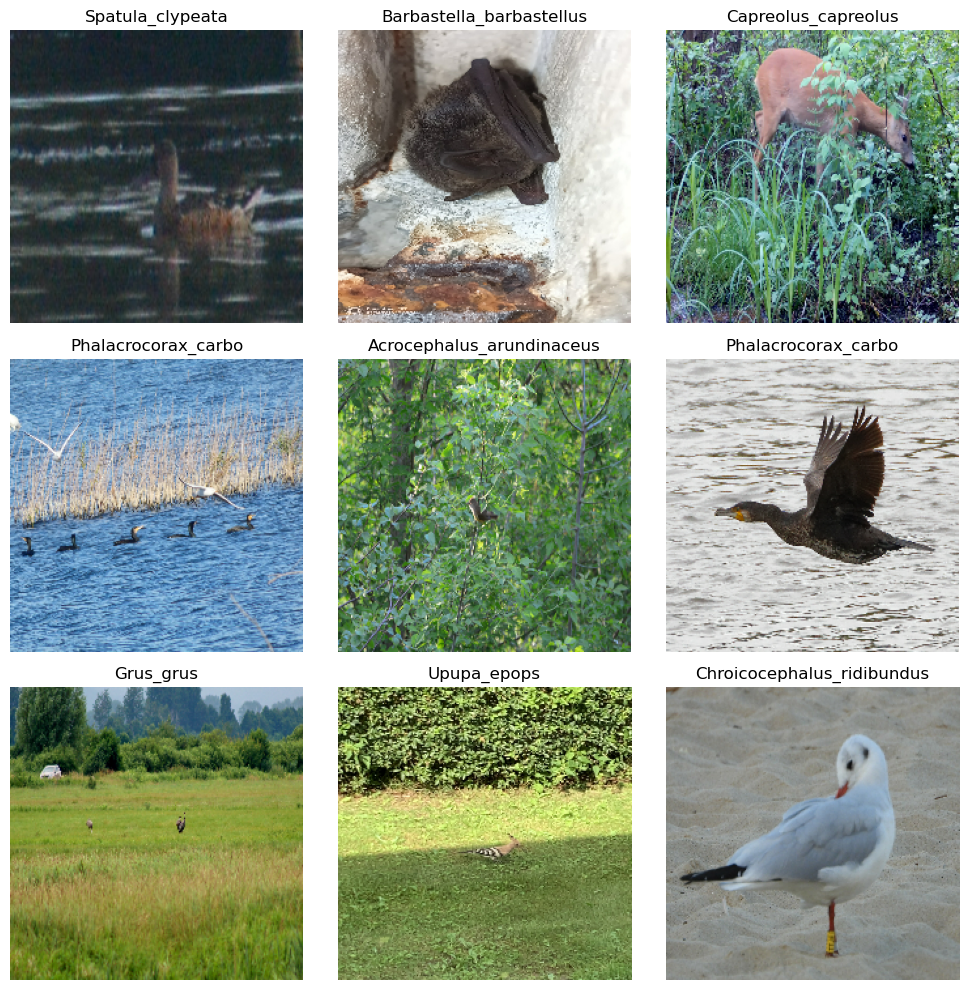

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Images are loaded as float32 in [0, 255]
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

### Dataset optimalizálása
prefetch alkalmazása, hogy elkerüljük a bottleneck-eket adatok betöltésekor

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## 4. Model megszerkesztése
ConvNeXtBase előre tanított modell alkalmazása backbone-ként. Backbone layerek fagyasztása, hogy csak az új fejet tanítsuk a datasetem

In [7]:
print("Building model...")
base_model = ConvNeXtBase(
    weights='imagenet',
    include_top=False,
    input_shape=image_size + (3,)
)

# Freeze the base model to only train the new head
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Building model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 56, 56,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ add[0][0]         │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st

 Total params: 88,175,314 (336.36 MB)

 Trainable params: 608,850 (2.32 MB)

 Non-trainable params: 87,566,464 (334.04 MB)

## 5. Modell betanítása
check-pointok létrehozása

In [7]:
os.makedirs(checkpoint_dir, exist_ok=True)

backup_callback = BackupAndRestore(backup_dir=os.path.join(checkpoint_dir, 'backup'))

checkpoint_callback = ModelCheckpoint(
    filepath="wildlife_classifier_best.keras",
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[backup_callback, checkpoint_callback, early_stopping]
)

Starting training...
Epoch 4/10


I0000 00:00:1772813088.239700   19059 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3724/3724 ━━━━━━━━━━━━━━━━━━━━ 13901s 4s/step - accuracy: 0.7208 - loss: 1.0053 - val_accuracy: 0.6828 - val_loss: 1.2409
Epoch 5/10
3724/3724 ━━━━━━━━━━━━━━━━━━━━ 13608s 4s/step - accuracy: 0.7322 - loss: 0.9567 - val_accuracy: 0.6829 - val_loss: 1.2419
Epoch 6/10
3724/3724 ━━━━━━━━━━━━━━━━━━━━ 13624s 4s/step - accuracy: 0.7382 - loss: 0.9259 - val_accuracy: 0.6867 - val_loss: 1.2496
Epoch 7/10
3724/3724 ━━━━━━━━━━━━━━━━━━━━ 13606s 4s/step - accuracy: 0.7449 - loss: 0.9017 - val_accuracy: 0.6870 - val_loss: 1.2587


In [8]:
model = tf.keras.models.load_model("wildlife_classifier_best.keras")
print("Best model loaded successfully!")

Best model loaded successfully!


## 6. tanulási adatok kiértékelése

NameError: name 'history' is not defined

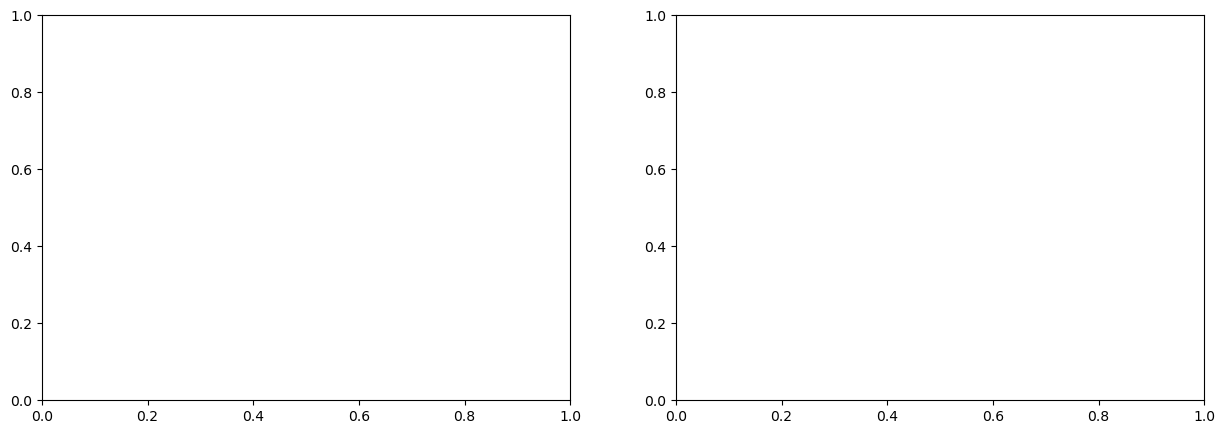

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Test set kiértékelése és végső modell mentése

In [10]:
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

model.save("wildlife_classifier_final.keras")
print("Final model saved as 'wildlife_classifier_final.keras'")

Evaluating on test set...


I0000 00:00:1773156190.051145     482 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


798/798 ━━━━━━━━━━━━━━━━━━━━ 2057s 3s/step - accuracy: 0.6860 - loss: 1.2422
Test accuracy: 0.6860, Test loss: 1.2422
Final model saved as 'wildlife_classifier_final.keras'


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


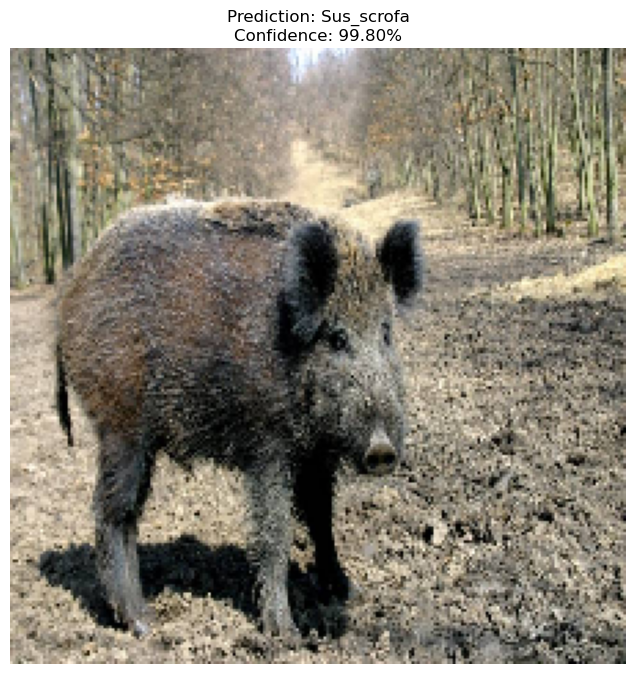

In [12]:
image_path = "vaddiszno.jpg"
target_size = (224, 224)
if os.path.exists(image_path):

    img = tf.keras.utils.load_img(image_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch of 1

    predictions = model.predict(img_array)
    score = predictions[0] # The output is already softmax probabilities
    class_idx = np.argmax(score)
    predicted_label = class_names[class_idx]
    confidence = 100 * score[class_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()
else:
    print(f"Error: File '{image_path}' not found in the current folder.")